<a href="https://colab.research.google.com/github/AnjanaGunarathna/DL_News_Detection/blob/Dinidi(BiLSTM)/fake_news_bi_lstm_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 2) Imports and reproducibility
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [ ]:
# Upload kaggle.json and download dataset automatically
from google.colab import files
files.upload()  # Upload kaggle.json (from your Kaggle account)

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!mkdir -p ./data
!kaggle datasets download -d clmentbisaillon/fake-and-real-news-dataset -p ./data
!unzip -q ./data/fake-and-real-news-dataset.zip -d ./data

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset
License(s): CC-BY-NC-SA-4.0
  0% 0.00/41.0M [00:00<?, ?B/s]
100% 41.0M/41.0M [00:00<00:00, 1.08GB/s]


In [ ]:
# 3) Load CSVs
fake_path = './data/Fake.csv'
true_path = './data/True.csv'

if not (os.path.exists(fake_path) and os.path.exists(true_path)):
  raise FileNotFoundError('Expected data/Fake.csv and data/True.csv. Download the Kaggle dataset and unzip to ./data')

df_fake = pd.read_csv(fake_path)
df_true = pd.read_csv(true_path)


print('Fake shape:', df_fake.shape)
print('True shape:', df_true.shape)


# quick peek
print(df_fake.columns)
print(df_true.columns)

Fake shape: (23481, 4)
True shape: (21417, 4)
Index(['title', 'text', 'subject', 'date'], dtype='object')
Index(['title', 'text', 'subject', 'date'], dtype='object')


In [ ]:
# 4) Combine and label
df_fake['label'] = 1 # 1 = fake
df_true['label'] = 0 # 0 = real


# keep only useful columns (title + text are useful). We'll use 'text' primarily.
for col in ['title','text','subject','date','label']:
  if col not in df_fake.columns:
    print('Warning: column',col,'missing in Fake.csv')


df = pd.concat([df_fake[['title','text','label']], df_true[['title','text','label']]], axis=0).reset_index(drop=True)
print('Combined shape:', df.shape)


# shuffle
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

Combined shape: (44898, 3)


label
1    23481
0    21417
Name: count, dtype: int64
                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   

                                                text  label  
0  21st Century Wire says Ben Stein, reputable pr...      1  
1  WASHINGTON (Reuters) - U.S. President Donald T...      0  
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...      0  


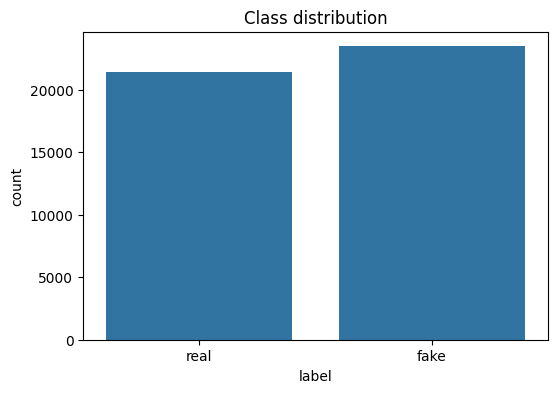

In [ ]:
# 5) Quick EDA
print(df['label'].value_counts())
print(df.head(3))


plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.xticks([0,1], ['real','fake'])
plt.title('Class distribution')
plt.show()

In [ ]:
# 6) Text cleaning / preprocessing
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
STOP = set(stopwords.words('english'))


def clean_text(text, remove_stopwords=True):
  text = str(text)
  text = text.lower()
  text = re.sub(r'\n', ' ', text)
  text = re.sub(r"http\S+|www\S+", ' ', text) # remove urls
  text = re.sub(r'[^a-z ]', ' ', text)
  tokens = text.split()
  if remove_stopwords:
    tokens = [t for t in tokens if t not in STOP]
  return ' '.join(tokens)


# apply (may take a minute)
df['clean_text'] = df['text'].astype(str).apply(lambda x: clean_text(x, remove_stopwords=True))


# quick check
print(df['clean_text'].str.len().describe())
print(df.loc[0, 'clean_text'][:300])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


count    44898.000000
mean      1722.097087
std       1533.043181
min          0.000000
25%        860.250000
50%       1506.000000
75%       2153.000000
max      38855.000000
Name: clean_text, dtype: float64
st century wire says ben stein reputable professor pepperdine university also hollywood fame appearing tv shows films ferris bueller day made provocative statements judge jeanine pirro show recently discussing halt imposed president trump executive order travel stein referred judgement th circuit co


In [ ]:
# 7) Baseline: TF-IDF + Logistic Regression (fast baseline)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


X = df['clean_text']
y = df['label'].values


# train/test split (stratified)
X_train_text, X_test_text, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)


tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)


lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)


preds_lr = lr.predict(X_test_tfidf)
print('\nBaseline (TF-IDF + LR) classification report:\n')
print(classification_report(y_test, preds_lr, digits=4))
print('ROC-AUC:', roc_auc_score(y_test, lr.predict_proba(X_test_tfidf)[:,1]))


# Save baseline artifacts
import pickle
os.makedirs('./artifacts', exist_ok=True)
with open('./artifacts/tfidf.pkl','wb') as f:
  pickle.dump(tfidf, f)
with open('./artifacts/lr_model.pkl','wb') as f:
  pickle.dump(lr, f)


Baseline (TF-IDF + LR) classification report:

              precision    recall  f1-score   support

           0     0.9833    0.9916    0.9874      4284
           1     0.9923    0.9847    0.9885      4696

    accuracy                         0.9880      8980
   macro avg     0.9878    0.9881    0.9880      8980
weighted avg     0.9880    0.9880    0.9880      8980

ROC-AUC: 0.9991353369854472


In [ ]:
# 8) Prepare data for deep learning (tokenize + pad)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


MAX_VOCAB = 20000
MAX_LEN = 300
EMBEDDING_DIM = 100


tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_text) # fit only on training set to avoid leakage


X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)


X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')


print('X_train_pad shape:', X_train_pad.shape)


# save tokenizer
with open('./artifacts/tokenizer.pkl','wb') as f:
  pickle.dump(tokenizer, f)

X_train_pad shape: (35918, 300)


In [ ]:
# 9) (Optional) Load GloVe embeddings and build embedding matrix
# Download GloVe (e.g., glove.6B.100d.txt). If you are in Colab, you can run:
# !wget http://nlp.stanford.edu/data/glove.6B.zip -P ./embeddings
# !unzip -q ./embeddings/glove.6B.zip -d ./embeddings
!mkdir -p ./embeddings
!wget http://nlp.stanford.edu/data/glove.6B.zip -P ./embeddings
!unzip -q ./embeddings/glove.6B.zip -d ./embeddings

# After you have glove.6B.100d.txt in ./embeddings, run the code below.
EMBEDDING_PATH = './embeddings/glove.6B.100d.txt' # change path if needed
use_glove = os.path.exists(EMBEDDING_PATH)

if use_glove:
  import numpy as np
  embeddings_index = {}
  with open(EMBEDDING_PATH, 'r', encoding='utf8') as f:
      for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs
  print('Loaded %d word vectors.' % len(embeddings_index))


word_index = tokenizer.word_index
nb_words = min(MAX_VOCAB, len(word_index) + 1)
embedding_matrix = np.zeros((nb_words, EMBEDDING_DIM))
for word, i in word_index.items():
  if i >= nb_words:
    continue
  embedding_vector = embeddings_index.get(word)
  if embedding_vector is not None:
    embedding_matrix[i] = embedding_vector
  print('Embedding matrix shape:', embedding_matrix.shape)
else:
  print('GloVe not found in', EMBEDDING_PATH, '- training embeddings from scratch.')

Streaming output truncated to the last 5000 lines.
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: (20000, 100)
Embedding matrix shape: 

In [ ]:
# 10) Build BiLSTM model (Keras)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SpatialDropout1D, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam


vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)


model = Sequential()
if use_glove:
  model.add(Embedding(vocab_size, EMBEDDING_DIM, weights=[embedding_matrix], input_length=MAX_LEN, trainable=False))
else:
  model.add(Embedding(vocab_size, EMBEDDING_DIM, input_length=MAX_LEN))


model.add(SpatialDropout1D(0.3))
model.add(Bidirectional(LSTM(128, dropout=0.2, recurrent_dropout=0.2)))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))


model.compile(loss='binary_crossentropy', optimizer=Adam(1e-3), metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)

In [ ]:
# 11) Train (with callbacks)
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
mc = ModelCheckpoint('./artifacts/best_bilstm.h5', monitor='val_loss', save_best_only=True)


history = model.fit(X_train_pad, y_train, batch_size=128, epochs=8, validation_split=0.1, callbacks=[es, mc])

Epoch 1/8
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9316 - loss: 0.1851

253/253 ━━━━━━━━━━━━━━━━━━━━ 834s 3s/step - accuracy: 0.9317 - loss: 0.1847 - val_accuracy: 0.9978 - val_loss: 0.0071
Epoch 2/8
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9972 - loss: 0.0137

253/253 ━━━━━━━━━━━━━━━━━━━━ 808s 3s/step - accuracy: 0.9972 - loss: 0.0137 - val_accuracy: 0.9983 - val_loss: 0.0050
Epoch 3/8
253/253 ━━━━━━━━━━━━━━━━━━━━ 909s 3s/step - accuracy: 0.9976 - loss: 0.0085 - val_accuracy: 0.9983 - val_loss: 0.0053
Epoch 4/8
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9984 - loss: 0.0069

253/253 ━━━━━━━━━━━━━━━━━━━━ 838s 3s/step - accuracy: 0.9984 - loss: 0.0070 - val_accuracy: 0.9989 - val_loss: 0.0038
Epoch 5/8
253/253 ━━━━━━━━━━━━━━━━━━━━ 825s 3s/step - accuracy: 0.9986 - loss: 0.0059 - val_accuracy: 0.9989 - val_loss: 0.0047
Epoch 6/8
253/253 ━━━━━━━━━━━━━━━━━━━━ 847s 3s/step - accuracy: 0.9984 - loss: 0.0053 - val_accuracy: 0.9994 - val_loss: 0.0040
Epoch 7/8
253/253 ━━━━━━━━━━━━━━━━━━━━ 823s 3s/step - accuracy: 0.9988 - loss: 0.0050 - val_accuracy: 0.9994 - val_loss: 0.0045


36/36 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step

BiLSTM classification report:

              precision    recall  f1-score   support

           0     0.9995    0.9979    0.9987      4284
           1     0.9981    0.9996    0.9988      4696

    accuracy                         0.9988      8980
   macro avg     0.9988    0.9987    0.9988      8980
weighted avg     0.9988    0.9988    0.9988      8980

ROC-AUC: 0.999838201890637


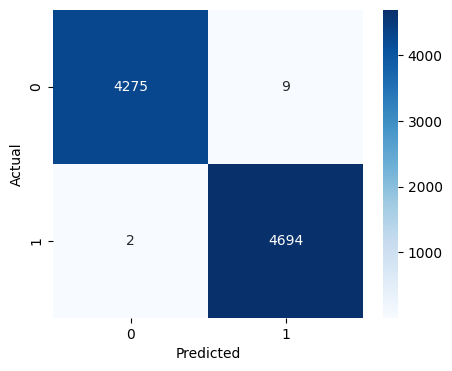

In [ ]:
# 12) Evaluate
pred_probs = model.predict(X_test_pad, batch_size=256)
preds = (pred_probs >= 0.5).astype(int).reshape(-1)


from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
print('\nBiLSTM classification report:\n')
print(classification_report(y_test, preds, digits=4))
print('ROC-AUC:', roc_auc_score(y_test, pred_probs))


# confusion matrix
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()